In [4]:
# Netflix Content Analytics Dashboard

## Objective

# Analyze Netflix Movies and TV Shows dataset using Python to perform data cleaning, exploratory data analysis (EDA), create visualizations,and generate business insights.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
df = pd.read_csv("netflix_titles.csv")

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Dick Johnson,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,A documentary about a father.
1,s2,TV Show,Blood & Water,Nosipho Dumisa,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas",A teenage girl investigates a family secret.
2,s3,Movie,The Starling,Theodore Melfi,Melissa McCarthy,United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman struggles after a tragic loss.
3,s4,Movie,Intrusion,Adam Salky,Freida Pinto,United States,"September 22, 2021",2021,TV-14,93 min,"Thrillers, Dramas",A woman becomes suspicious after a break-in.
4,s5,TV Show,Midnight Mass,Mike Flanagan,Zach Gilford,United States,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, Horror",A mysterious priest arrives on an island.


In [8]:
df.shape

(10, 12)

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       10 non-null     object
 1   type          10 non-null     object
 2   title         10 non-null     object
 3   director      10 non-null     object
 4   cast          10 non-null     object
 5   country       10 non-null     object
 6   date_added    10 non-null     object
 7   release_year  10 non-null     int64 
 8   rating        10 non-null     object
 9   duration      10 non-null     object
 10  listed_in     10 non-null     object
 11  description   10 non-null     object
dtypes: int64(1), object(11)
memory usage: 1.1+ KB


In [11]:
df.describe()

,release_year
count,10.00000
mean,2018.00000
std,7.90218
min,1996.00000
25%,2020.25000
50%,2021.00000
75%,2021.00000
max,2022.00000


In [12]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df=df.drop_duplicates()

In [15]:
df["director"]=df["director"].fillna("Unknown")
df["cast"]=df["cast"].fillna("Unknown")
df["country"]=df["country"].fillna("Unknown")
df["rating"]=df["rating"].fillna("Not Rated")

In [16]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

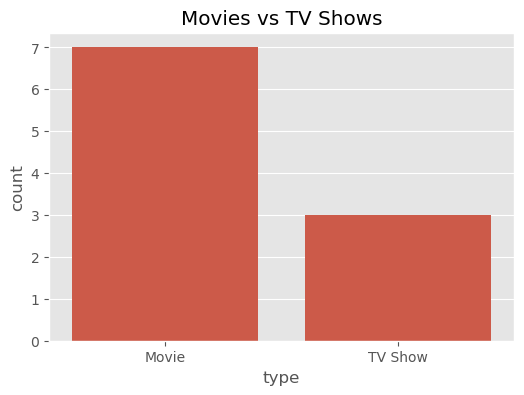

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="type")
plt.title("Movies vs TV Shows")
plt.show()

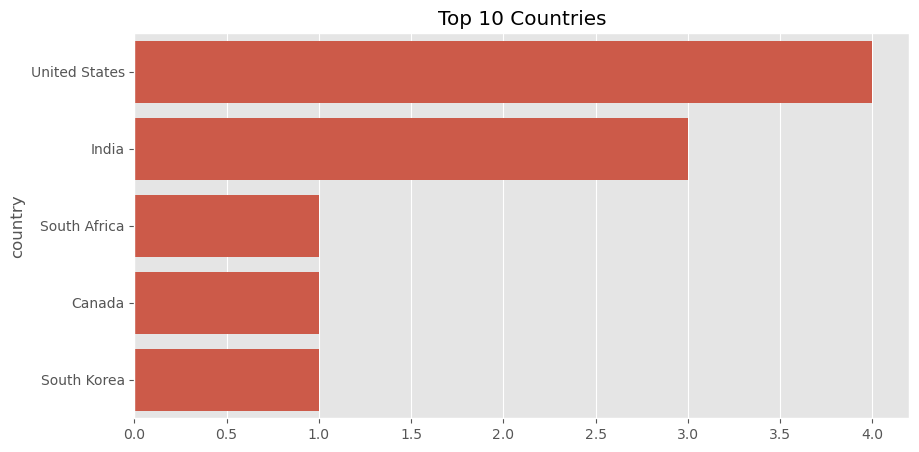

In [18]:
country=df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=country.values,y=country.index)

plt.title("Top 10 Countries")
plt.show()

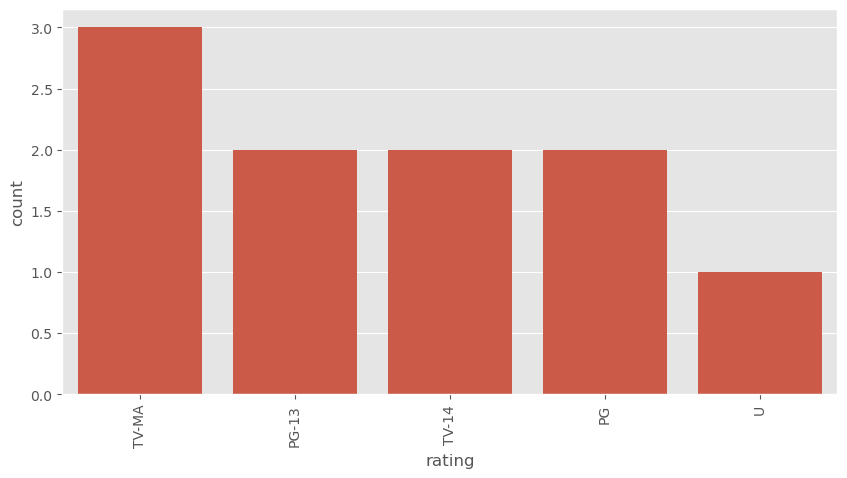

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="rating",
              order=df["rating"].value_counts().index)

plt.xticks(rotation=90)

plt.show()

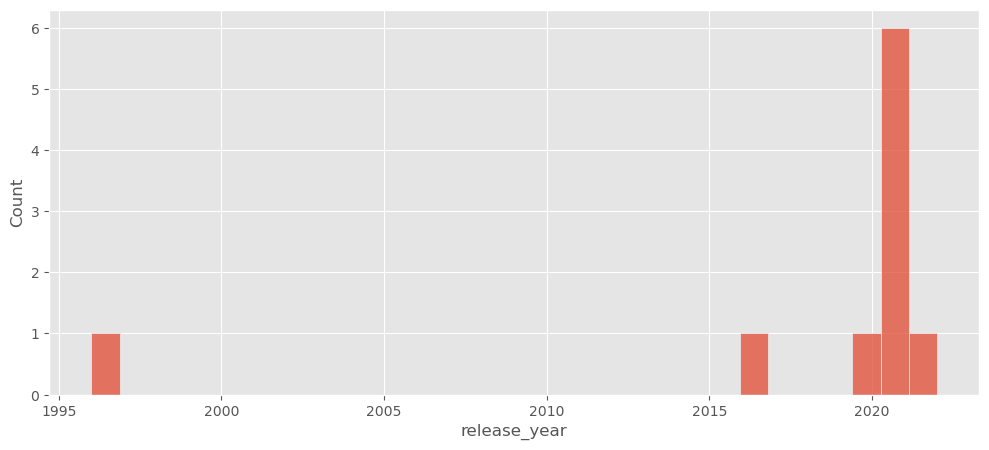

In [20]:
plt.figure(figsize=(12,5))

sns.histplot(df["release_year"],bins=30)

plt.show()

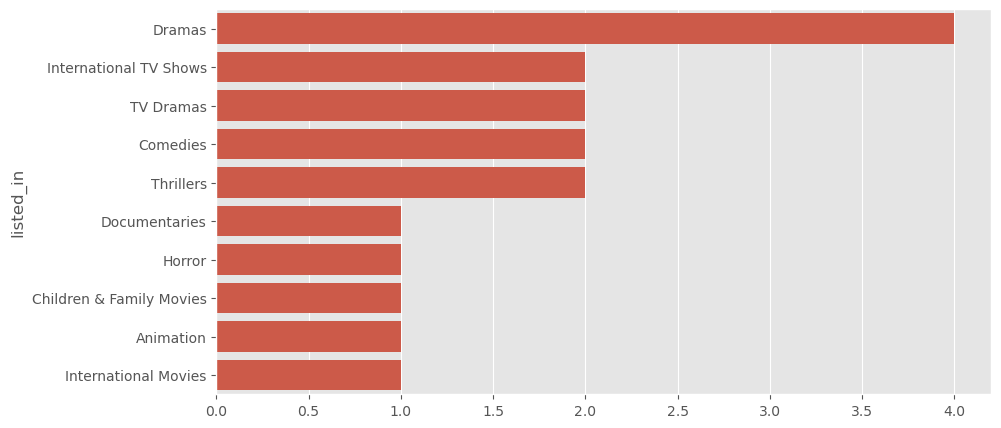

In [21]:
genre=df["listed_in"].str.split(", ").explode()

genre=genre.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=genre.values,y=genre.index)

plt.show()

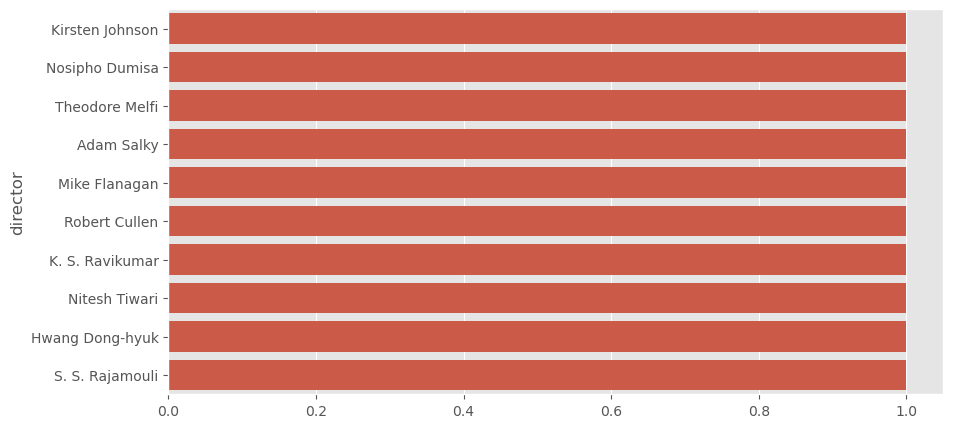

In [22]:
director=df[df["director"]!="Unknown"]["director"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=director.values,y=director.index)

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4448\950831258.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["duration"]=movies["duration"].str.replace(" min","")
C:\Users\DELL\AppData\Local\Temp\ipykernel_4448\950831258.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["duration"]=pd.to_numeric(movies["duration"])


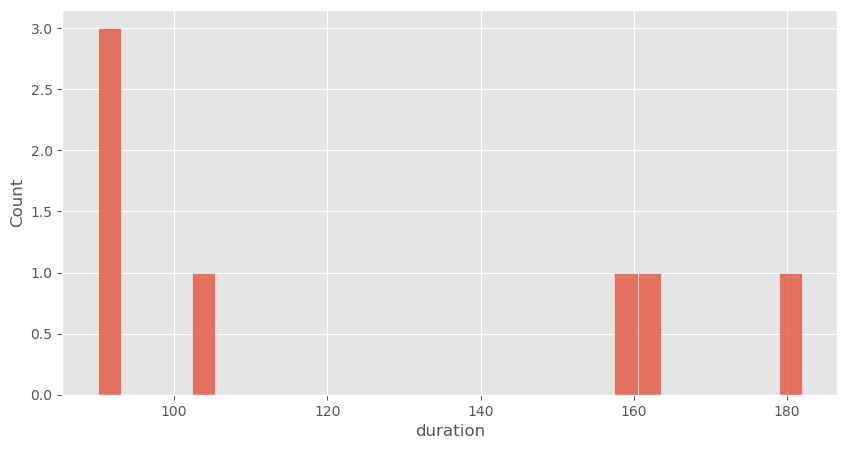

In [23]:
movies=df[df["type"]=="Movie"]

movies["duration"]=movies["duration"].str.replace(" min","")

movies["duration"]=pd.to_numeric(movies["duration"])

plt.figure(figsize=(10,5))

sns.histplot(movies["duration"],bins=30)

plt.show()

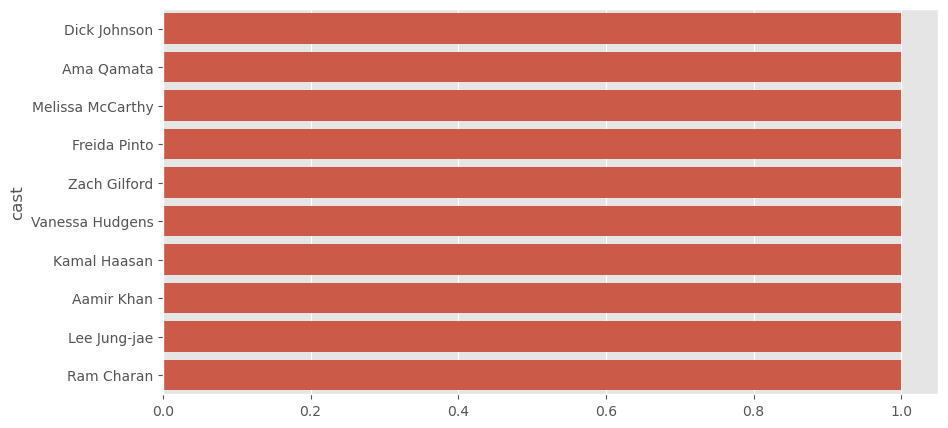

In [24]:
cast=df["cast"].str.split(", ").explode()

cast=cast[cast!="Unknown"]

top_cast=cast.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_cast.values,y=top_cast.index)

plt.show()

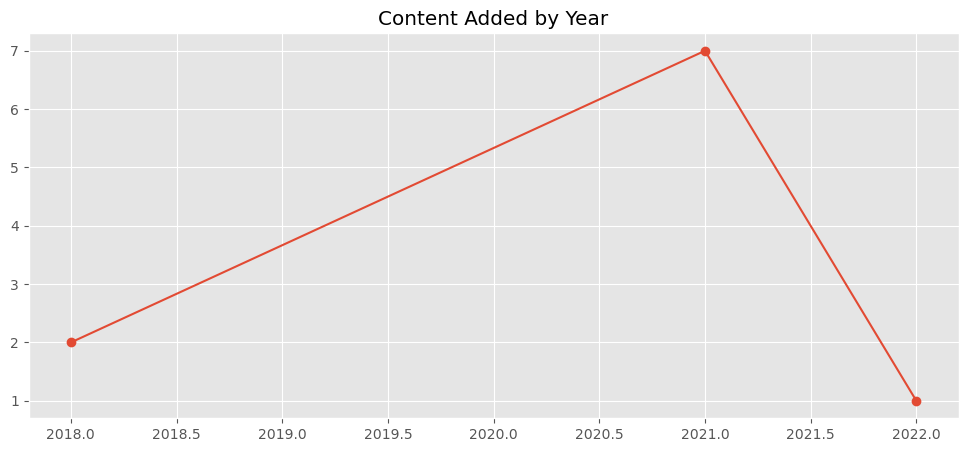

In [25]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")

added=df["date_added"].dt.year.value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(added.index,added.values,marker="o")

plt.title("Content Added by Year")

plt.show()

In [27]:
## Business Insights

# • Movies dominate Netflix content.

# • USA contributes the highest number of titles.

# • Drama and International Movies are the most popular genres.

# • Netflix rapidly expanded its library after 2015.

# • TV-MA is the most common content rating.

# • Content is available from multiple countries, indicating a global strategy.

In [28]:
## Conclusion

# The Netflix Content Analytics project successfully analyzed the Netflix dataset using Python. Data cleaning, exploratory data analysis,
# and visualizations revealed important trends in content type, genre, release year, ratings, and country distribution.
# These insights can help understand Netflix's content strategy and audience preferences.